In [1]:
%matplotlib inline
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.style.use('seaborn-white')
import multiprocess as mp
import numpy as np
import pandas as pd
import cooltools
import cooler
import bbi
import bioframe
import glob, os
from matplotlib_venn import venn2
from pandas.api.types import CategoricalDtype

/tmp/ipykernel_33500/1160891744.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


In [2]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [8]:
TimeCourse=["OU-HiC-N6IPSC2-EP-W0","OU-HiC-N6IPSC2-MN-W0","OU-HiC-N6IPSC2-MN-W3","OU-HiC-N6IPSC2-MN-W6"]

48366   17148
47012   16211
36689   14521
33008   13599


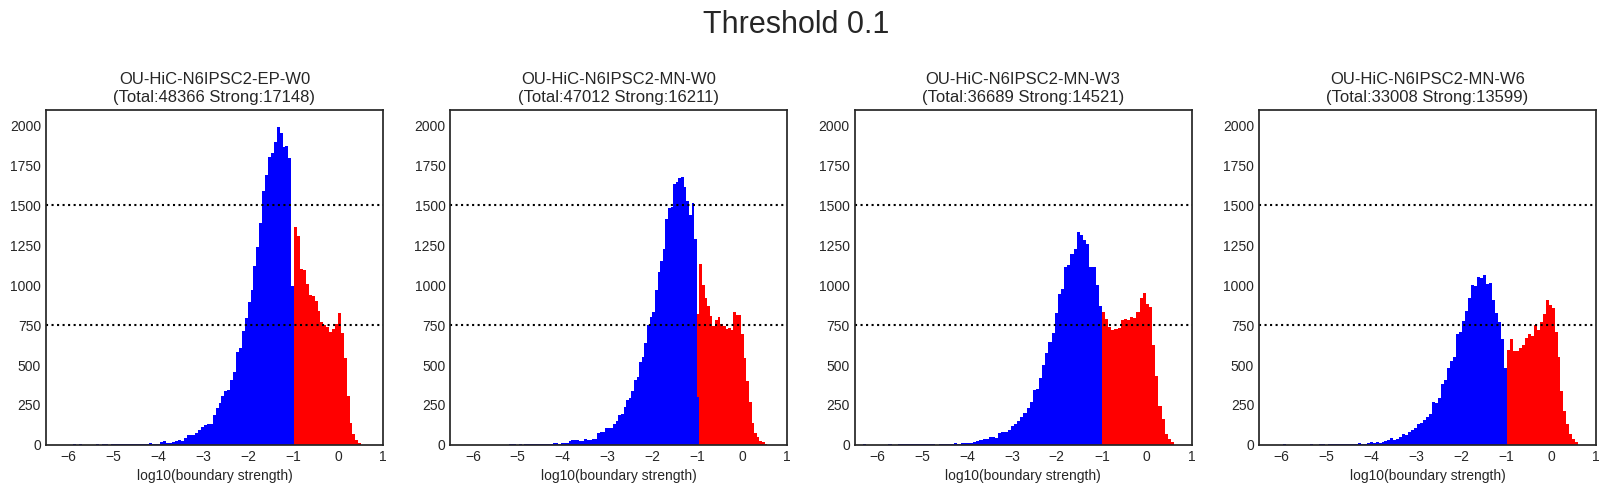

In [9]:
gs = GridSpec(nrows=2, ncols=4,hspace=0.3)
plt.figure(figsize=(20,10))


for i in range(len(TimeCourse)):
    insulations = pd.read_csv("../cooltools54/Insulation/10kb_bins_100kb_win/"+TimeCourse[i]+"_10kb_bin_100kb_win_insulation",sep='\t')
    insulations = insulations.dropna()
    #print(insulations.head(5))
    strong_weak = insulations
    #strong_weak=insulations[insulations["boundary_strength_100000"] !=0](same as insulations)
    x = np.log10(strong_weak['boundary_strength_100000'].values)
    #x=strong_weak['boundary_strength_100000'].values
    bins = np.linspace(x.min(), x.max(), num=100)
    #mask=strong_weak["boundary_strength_100000"].values >= 0.5
    mask=insulations["boundary_strength_100000"].values >= 0.1
    ax = plt.subplot(gs[i])
    ax.set_xlabel('log10(boundary strength)')
    #ax.hist(x, bins=bins, color='grey',density=False)
    ax.hist(x[mask], bins=bins, color='r',density=False)
    ax.hist(x[~mask], bins=bins, color='b',density=False)
    plt.ylim(0,2100)
    plt.xlim(-6.5,1)
    plt.axhline(y=750, color='black', linestyle=':')
    plt.axhline(y=1500, color='black', linestyle=':')
    ax.set_title(TimeCourse[i]+"\n(Total:"+str(len(strong_weak))+" Strong:"+str(len(x[mask]))+")")
    print(len(strong_weak)," ",len(x[mask]))
    plt.suptitle("Threshold 0.1",fontsize=22)
#plt.savefig("Insulation/TimeCourse-threshold-0.5.pdf")
#plt.savefig("Plots/TimeCourse-threshold-0.5.pdf")